In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
cd '/content/drive/MyDrive/Colab Notebooks/music genre classification '


/content/drive/MyDrive/Colab Notebooks/music genre classification 


In [10]:
ls


 1.feature_extraction.ipynb          features.csv
 2.exploratory_data_analysis.ipynb   gtzan-dataset-music-genre-classification/
'3.model training.ipynb'             music_genre_cnn.h5
'4.CNN Trainer.ipynb'               'Trained Models'/
'5.Model Evaluator.ipynb'


In [11]:
cd 'Trained Models'/

/content/drive/MyDrive/Colab Notebooks/music genre classification /Trained Models


In [12]:

    # Load the scaler object
scaler = joblib.load('scaler.joblib')

    # Load the trained models
log_reg_model = joblib.load('logistic_regression_model.joblib')
svm_model = joblib.load('svm_model.joblib')
rf_model = joblib.load('random_forest_model.joblib')

In [13]:
cd ..

/content/drive/MyDrive/Colab Notebooks/music genre classification 


In [14]:
# Import necessary libraries
import pandas as pd
import numpy as np
import joblib # For loading scikit-learn models and scaler
import tensorflow as tf # For loading the Keras model
from sklearn.model_selection import train_test_split

print("--- Model Evaluation Script ---")

try:
    # --- 1. Load and Prepare the Test Data ---
    print("\n[1/4] Loading and preparing test data...")

    # Load the full feature set
    features_df = pd.read_csv("features.csv")

    # Separate features (X) and target (y)
    X = features_df.drop('label', axis=1)
    y = features_df['label']

    # CRUCIAL: Split the data using the *exact same* parameters as in training
    # This ensures we get the identical test set that the models have never seen.
    _, X_test, _, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    print("Test data loaded and split successfully.")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_test shape: {y_test.shape}")

    # --- 2. Load the scikit-learn Models and the Scaler ---
    print("\n[2/4] Loading scikit-learn models and scaler...")


    print("Scikit-learn assets loaded successfully.")
    print(f"Scaler: {type(scaler)}")
    print(f"Logistic Regression Model: {type(log_reg_model)}")
    print(f"SVM Model: {type(svm_model)}")
    print(f"Random Forest Model: {type(rf_model)}")

    # --- 3. Load the Keras CNN Model ---
    print("\n[3/4] Loading Keras CNN model...")

    # Use TensorFlow/Keras to load the HDF5 file
    cnn_model = tf.keras.models.load_model('music_genre_cnn.h5')

    print("Keras CNN model loaded successfully.")
    print(f"CNN Model: {type(cnn_model)}")
    # Optional: Display the CNN model's architecture
    # cnn_model.summary()

    # --- 4. Prepare Test Data for Different Model Types ---
    print("\n[4/4] Preparing test data for model predictions...")

    # For scikit-learn models, we only need to scale the data.
    X_test_scaled = scaler.transform(X_test)
    print(f"Shape of X_test_scaled (for scikit-learn): {X_test_scaled.shape}")

    # For the CNN model, we need to scale AND reshape the data to 3D.
    X_test_cnn = np.expand_dims(X_test_scaled, axis=-1)
    print(f"Shape of X_test_cnn (for Keras): {X_test_cnn.shape}")

    print("\nAll models and data are loaded and ready for evaluation!")

     # --- 5. Generate Predictions for Each Model ---
    print("\n[5/5] Generating predictions on the test set...")

    # --- a) Scikit-learn Models ---
    # The .predict() method directly returns the predicted class label (0-9).
    y_pred_log_reg = log_reg_model.predict(X_test_scaled)
    y_pred_svm = svm_model.predict(X_test_scaled)
    y_pred_rf = rf_model.predict(X_test_scaled)

    print("Predictions generated for scikit-learn models.")

    # --- b) Keras CNN Model ---
    # The .predict() method returns a 2D array of class probabilities.
    y_pred_cnn_probs = cnn_model.predict(X_test_cnn)
    # We use np.argmax() to find the index of the class with the highest probability.
    # The 'axis=1' argument is crucial: it tells argmax to find the maximum value
    # for each sample (row) across all the class probabilities (columns).
    y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

    print("Predictions generated for Keras CNN model.")

    # --- Verification Step ---
    # Let's check the shapes of our prediction arrays. They should all have
    # a length equal to the number of samples in our test set (2500).
    print("\n--- Verifying Prediction Shapes ---")
    print(f"Logistic Regression Predictions Shape: {y_pred_log_reg.shape}")
    print(f"SVM Predictions Shape: {y_pred_svm.shape}")
    print(f"Random Forest Predictions Shape: {y_pred_rf.shape}")
    print(f"CNN Predictions Shape: {y_pred_cnn.shape}")

    print("\nAll predictions have been generated successfully!")
except FileNotFoundError as e:
    print(f"\nERROR: A required file was not found: {e.filename}")
    print("Please ensure all model files ('scaler.joblib', '*.joblib', 'music_genre_cnn.h5') and 'features.csv' are in the correct directory.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


--- Model Evaluation Script ---

[1/4] Loading and preparing test data...
Test data loaded and split successfully.
X_test shape: (2498, 28)
y_test shape: (2498,)

[2/4] Loading scikit-learn models and scaler...
Scikit-learn assets loaded successfully.
Scaler: <class 'sklearn.preprocessing._data.StandardScaler'>
Logistic Regression Model: <class 'sklearn.linear_model._logistic.LogisticRegression'>
SVM Model: <class 'sklearn.svm._classes.SVC'>
Random Forest Model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>

[3/4] Loading Keras CNN model...


Keras CNN model loaded successfully.
CNN Model: <class 'keras.src.models.sequential.Sequential'>

[4/4] Preparing test data for model predictions...
Shape of X_test_scaled (for scikit-learn): (2498, 28)
Shape of X_test_cnn (for Keras): (2498, 28, 1)

All models and data are loaded and ready for evaluation!

[5/5] Generating predictions on the test set...
Predictions generated for scikit-learn models.
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predictions generated for Keras CNN model.

--- Verifying Prediction Shapes ---
Logistic Regression Predictions Shape: (2498,)
SVM Predictions Shape: (2498,)
Random Forest Predictions Shape: (2498,)
CNN Predictions Shape: (2498,)

All predictions have been generated successfully!


In [16]:
from sklearn.metrics import classification_report
genre_names = [
        'blues', 'classical', 'country', 'disco', 'hiphop',
        'jazz', 'metal', 'pop', 'reggae', 'rock'
    ]

print("\n" + "="*60)
print("      Classification Report: Logistic Regression")
print("="*60)
print(classification_report(y_test, y_pred_log_reg, target_names=genre_names))

print("\n" + "="*60)
print("      Classification Report: Support Vector Machine (SVM)")
print("="*60)
print(classification_report(y_test, y_pred_svm, target_names=genre_names))

print("\n" + "="*60)
print("      Classification Report: Random Forest")
print("="*60)
print(classification_report(y_test, y_pred_rf, target_names=genre_names))

print("\n" + "="*60)
print("      Classification Report: Convolutional Neural Network (CNN)")
print("="*60)
print(classification_report(y_test, y_pred_cnn, target_names=genre_names))


      Classification Report: Logistic Regression
              precision    recall  f1-score   support

       blues       0.41      0.27      0.32       250
   classical       0.58      0.63      0.60       250
     country       0.69      0.78      0.73       250
       disco       0.77      0.87      0.82       250
      hiphop       0.48      0.44      0.46       250
        jazz       0.54      0.50      0.52       250
       metal       0.50      0.52      0.51       250
         pop       0.54      0.59      0.56       250
      reggae       0.56      0.52      0.54       248
        rock       0.79      0.86      0.82       250

    accuracy                           0.60      2498
   macro avg       0.58      0.60      0.59      2498
weighted avg       0.58      0.60      0.59      2498


      Classification Report: Support Vector Machine (SVM)
              precision    recall  f1-score   support

       blues       0.67      0.57      0.61       250
   classical       0.82

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
# --- 7. Compute the Confusion Matrix for Each Model ---

print("\n" + "="*60)
print("           Computing Confusion Matrices")
print("="*60)

cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

print("\n--- Logistic Regression Confusion Matrix (raw) ---")
print(cm_log_reg)
print(f"Shape: {cm_log_reg.shape}") # Should be (10, 10)

print("\n--- SVM Confusion Matrix (raw) ---")
print(cm_svm)

print("\n--- Random Forest Confusion Matrix (raw) ---")
print(cm_rf)

print("\n--- CNN Confusion Matrix (raw) ---")
print(cm_cnn)

print("\nConfusion matrices computed successfully.")


           Computing Confusion Matrices

--- Logistic Regression Confusion Matrix (raw) ---
[[ 67  28   9  12  35  11  48  16  22   2]
 [ 22 157   0  15  13   9  13   4  10   7]
 [  0   0 196   0   7  10  14  11  11   1]
 [  6   7   1 217   1   2  10   4   1   1]
 [ 31  32  12   1 110  16   8   9  25   6]
 [  9  17  13   3  15 124   9  42  16   2]
 [ 17   7  23   8  14  14 130  28   4   5]
 [  3   4  24  25   6  22  15 147   0   4]
 [  1  19   6   1  17  19  13  13 128  31]
 [  7   2   0   0  10   2   2   0  11 216]]
Shape: (10, 10)

--- SVM Confusion Matrix (raw) ---
[[142  14   5   8  26  10  27   9   9   0]
 [  5 212   0   9   8   5   3   2   3   3]
 [  6   0 202   0   6   7   9  10   9   1]
 [  6   5   0 223   2   1   9   4   0   0]
 [ 22  11   7   2 171   8   8   2  17   2]
 [  8   4   9   1   9 181  15  19   4   0]
 [ 14   5  20   8   7   5 175  12   4   0]
 [  3   1  10  14   7  11  10 191   1   2]
 [  5   7   4   0  14   9   4   3 182  20]
 [  1   1   0   0   7   0   0   0   4

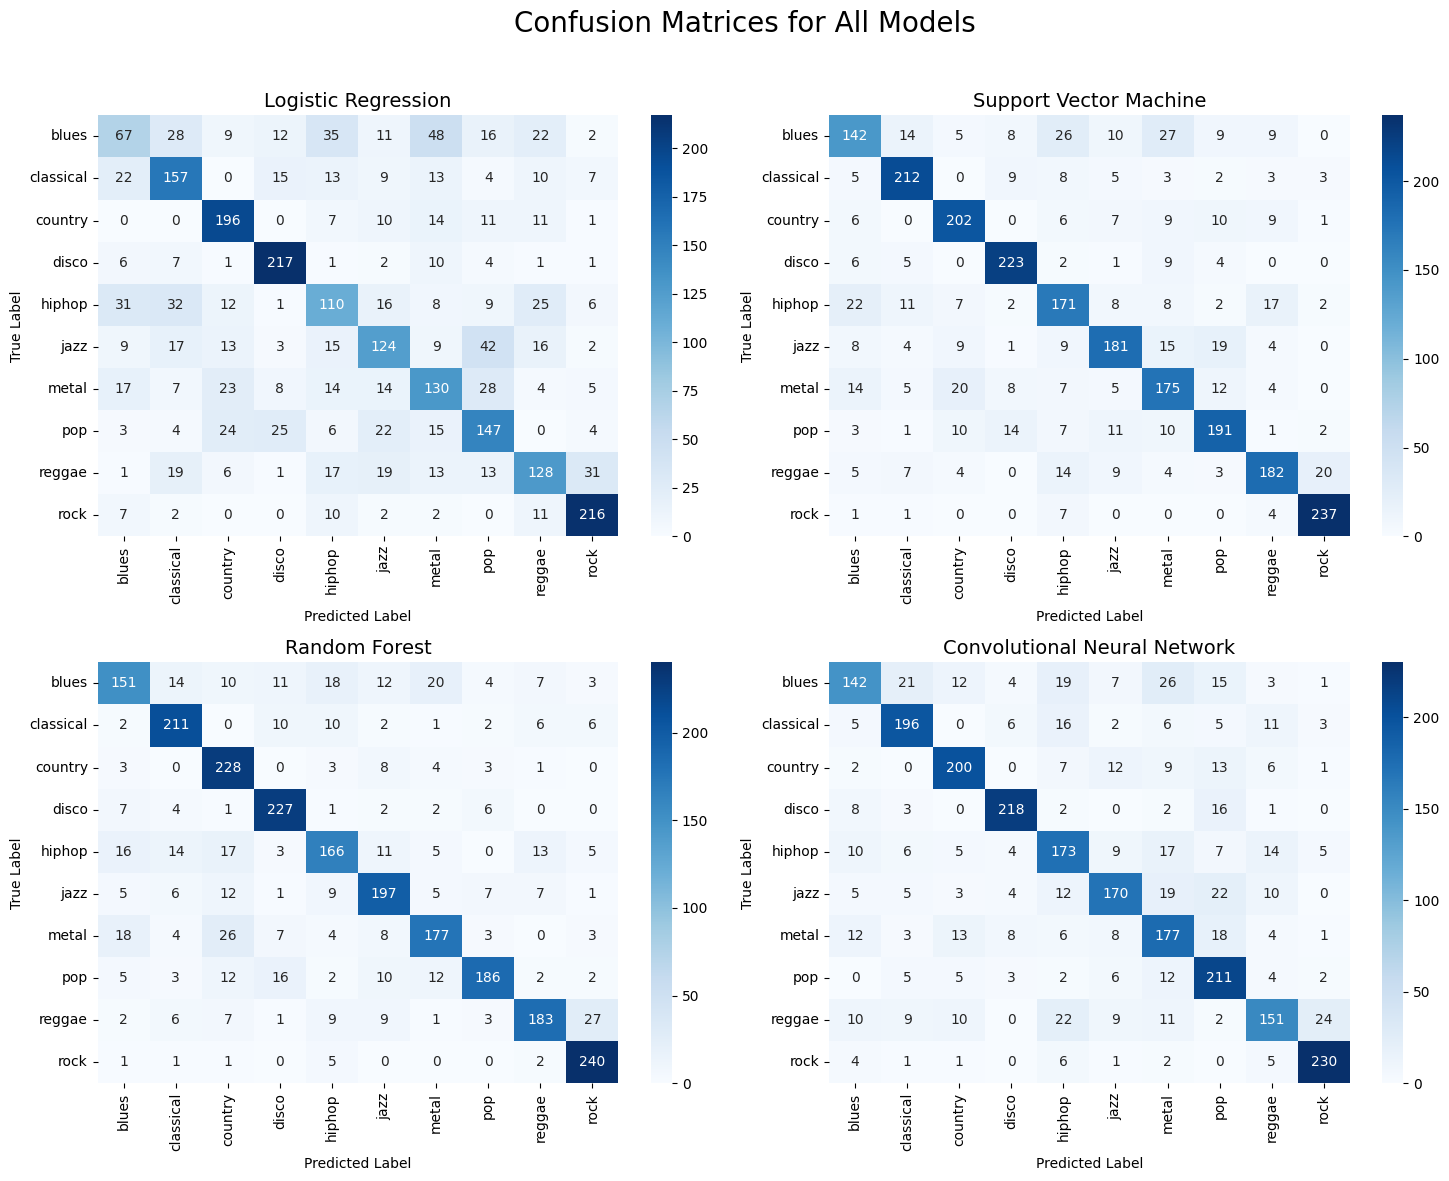

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
def plot_confusion_matrix(cm, labels, title, ax):
  sns.heatmap(
            cm,                  # The confusion matrix data
            annot=True,          # Annotate each cell with its value
            fmt='d',             # Format the annotation as an integer
            cmap='Blues',        # Use the 'Blues' color map
            xticklabels=labels,  # Set the x-axis labels
            yticklabels=labels,  # Set the y-axis labels
            ax=ax                # Plot on the provided subplot axis
        )
  ax.set_title(title, fontsize=14)
  ax.set_xlabel('Predicted Label')
  ax.set_ylabel('True Label')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Confusion Matrices for All Models', fontsize=20)

    # Plot each confusion matrix on its respective subplot
plot_confusion_matrix(cm_log_reg, genre_names, 'Logistic Regression', axes[0, 0])
plot_confusion_matrix(cm_svm, genre_names, 'Support Vector Machine', axes[0, 1])
plot_confusion_matrix(cm_rf, genre_names, 'Random Forest', axes[1, 0])
plot_confusion_matrix(cm_cnn, genre_names, 'Convolutional Neural Network', axes[1, 1])

    # Adjust the layout to prevent titles and labels from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.96]) # rect is used to make space for suptitle

    # Display the final figure
plt.show()